In [1]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from pydantic import BaseModel

In [2]:
load_dotenv()

True

In [3]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [4]:
class StudentState(TypedDict):
    name: str
    subjects: list[str]
    marks: list[int]
    grade: list[str]
    feedback: str
    weaknesses: str
    strengths: str
    report: str

In [5]:
def validate_student(state: StudentState):
    if len(state["subjects"]) != len(state["marks"]):
        for mark in state["marks"]:
            if mark < 0 or mark > 100:
                raise ValueError("Marks should be between 0 and 100")
        print('Student data is vaild')

    return state

In [6]:
class GradeOutput(BaseModel):
    grade: list[str]

In [7]:
def calculate_grade(state: StudentState):
    structured_llm = llm.with_structured_output(GradeOutput)

    response = structured_llm.invoke(
        f"""
            You are a college teacher.
            student Marks: {state['marks']}

            Give only the grade.

            Rules

            90-100 = A+
            80-89 = A
            70-79 = B
            60-69 = C

            Below 60 - Fail  
        """
    )
    state["grade"] = response.grade
    print('Grade: ', state["grade"])
    return state

In [8]:
class FeedbackOutput(BaseModel):
    strengths: str
    weaknesses: str
    feedback: str

In [9]:
def generate_feedback(state: StudentState):
    print("\n========== Feedback Node ==========")

    structured_llm = llm.with_structured_output(FeedbackOutput)
    response = structured_llm.invoke(
        f"""
        You are an experienced Python teacher

        Student Name : {state['name']}
        Subject: {state['subjects']}
        Marks: {state['marks']}
        Grade: {state['grade']}

        Generate
        
        1. Student strengths

        2. Student weaknesses

        3. Personalized teacher feedback

        Keep the response short and professional.
        """
    )

    state["strengths"] = response.strengths
    state["weaknesses"] = response.weaknesses
    state["feedback"] = response.feedback

    return state

In [10]:
def generate_report (state: StudentState):
    print("\n========== Report Node ==========")


    report = f"""
=========================================
          AI STUDENT REPORT
=========================================

Student Name : {state["name"]}

Subject      : {state["subjects"]}

Marks        : {state["marks"]}

Grade        : {state["grade"]}


Strengths
----------
{state["strengths"]}


Weaknesses
-----------
{state["weaknesses"]}


Teacher Feedback
----------------
{state["feedback"]}

=========================================
"""

    state["report"] = report

    return state

In [11]:
builder = StateGraph(StudentState)

builder.add_node("validate", validate_student)
builder.add_node("grade",calculate_grade)
builder.add_node("feedback", generate_feedback)
builder.add_node("report", generate_report)

In [12]:
builder.add_edge(START, "validate")
builder.add_edge("validate", "grade")
builder.add_edge("grade", "feedback")
builder.add_edge("feedback", "report")
builder.add_edge("report", END)

In [13]:
graph = builder.compile()

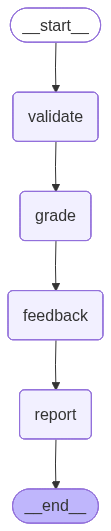

In [14]:
graph

In [15]:
student = {

    "name": "Mohit",

    "subjects": ["python", "C++", "javascripts"],

    "marks": [89,87,90],

    "grade": [],

    "strengths": "",

    "weaknesses": "",

    "feedback": "",

    "report": ""
}

In [16]:
result = graph.invoke(student)

Grade:  ['B', 'A', 'A+']

========== Feedback Node ==========

========== Report Node ==========


In [17]:
print(result["report"])


          AI STUDENT REPORT

Student Name : Mohit

Subject      : ['python', 'C++', 'javascripts']

Marks        : [89, 87, 90]

Grade        : ['B', 'A', 'A+']


Strengths
----------
javascripts


Weaknesses
-----------
None


Teacher Feedback
----------------
Mohit shows exceptional skills in javascripts and decent performance in python and C++. Focus on consistency to achieve better grades.


